In [2]:
!pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
name=[1,2,3,4,5,6,7,8,'type']
df=pd.read_csv("magic04.data",names=name)
df.head()


In [ ]:
for label in df['type'].unique():
  plt.hist(df[df['type']==label][1],color='red',label='gamma',alpha=0.5,density='True')
  plt.hist(df[df['type']==label][0],color='green',label='hedron',alpha=0.8,density='True')
  plt.legend()
  plt.show()

In [ ]:
def dataset(df):
    x = df.iloc[:, :-1].values 
    y = df.iloc[:, -1].values 
    scaler = StandardScaler()
    x = scaler.fit_transform(x) 
    data = np.hstack((x, np.reshape(y, (-1, 1)))) 
    return data, x, y
print(5)
data, x, y = dataset(df)

In [ ]:
df=pd.read_csv("co2.csv")
df.head()
train,validation,test= np.split(df.sample(frac=1,random_state=42),[int(0.6*len(df)),int(0.8*len(df))])
def dataset(df):
    x = df.iloc[:, :-1].values 
    y = df.iloc[:, -1].values   
    data = np.hstack((x, np.reshape(y, (-1, 1))))  
    return  x, y
x_train, y_train = dataset(train)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train) 
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model=model.fit(x_train,y_train)

In [ ]:
print(df.columns)


In [ ]:
print("All columns in x_train:", x_train.columns.tolist())



In [ ]:
print([col for col in x_train.columns if 'CO2' in col])


In [ ]:
x_train.rename(columns={"CO2 Emissions(g/km)": "CO2 Emissions(g/km)"}, inplace=True)
print("All columns in x_train:", x_train.columns.tolist())


In [ ]:
print([repr(col) for col in x_train.columns])

In [7]:
#log

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
file_path = 'co2.csv' 
data = pd.read_csv(file_path)
label_encoder = LabelEncoder()
data['Transmission'] = label_encoder.fit_transform(data['Transmission'])
data = pd.get_dummies(data, columns=['Make', 'Fuel Type', 'Vehicle Class'], drop_first=True)
data = data.drop(['Model'], axis=1)
X = data.drop(['Transmission'], axis=1)
y = data['Transmission']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))




NameError: name 'model' is not defined

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
file_path = 'co2.csv' 
data = pd.read_csv(file_path)
columns = ['Make', 'Vehicle Class', 'Transmission', 'Fuel Type']
X = data.drop(['CO2 Emissions(g/km)', 'Model'], axis=1) 
y = data['CO2 Emissions(g/km)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Intercept:", model.intercept_)


ValueError: could not convert string to float: 'BMW'

In [3]:
## doubt not cleared 

import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
file_path = 'co2.csv'  
data = pd.read_csv(file_path)
data = pd.get_dummies(data, columns=['Make', 'Transmission', 'Fuel Type', 'Vehicle Class'], drop_first=True)
X = data.drop(['CO2 Emissions(g/km)'], axis=1)
y = data['CO2 Emissions(g/km)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = tf.keras.Sequential([tf.keras.layers.Input(shape=(X_train.shape[1],)),tf.keras.layers.Dense(1)  ])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)
y_pred = model.predict(X_test).flatten()
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

ModuleNotFoundError: No module named 'tensorflow'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
f = 'co2.csv'  
data = pd.read_csv(f)
cat_columns = ['Make', 'Vehicle Class', 'Transmission', 'Fuel Type']
X = data.drop(['CO2 Emissions(g/km)', 'Model'], axis=1)
y = data['CO2 Emissions(g/km)']
ct = ColumnTransformer(transformers=[('onehot', OneHotEncoder(drop='first'), cat_columns)],remainder='passthrough'  )
X = ct.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Intercept:", model.intercept_)


Mean Squared Error: 25.7350237164793
R-squared: 0.9923559293763351
Intercept: 86.6436503443035


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
f = 'co2.csv'  
df = pd.read_csv(f)
x = df['Engine Size(L)']
y = df['CO2 Emissions(g/km)']

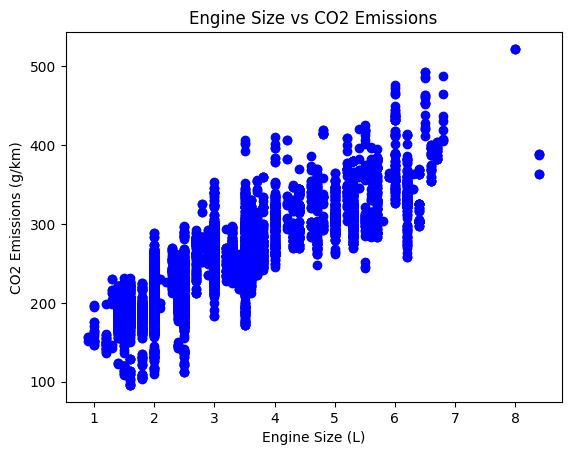

In [2]:
plt.scatter(x, y, color='blue', label='Data points')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.title('Engine Size vs CO2 Emissions')
plt.show()

In [3]:
x_mean=np.mean(x)
y_mean=np.mean(y)
numerator=np.sum((x - x_mean) * (y - y_mean))  
denominator=np.sum((x - x_mean) ** 2)          
m=numerator/denominator                     
b=y_mean-m*x_mean                          
y_pred=m*x+b
mse=np.mean((y-y_pred)**2)
rmse=(mse)**0.5
ss_total=np.sum((y-y_mean)**2)       
ss_res = np.sum((y-y_pred)**2) 
r2=1-(ss_res/ss_total)

In [4]:
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2:{r2}")

MSE: 943.2916297051705
RMSE: 30.713053083423187
R2:0.724447204652408


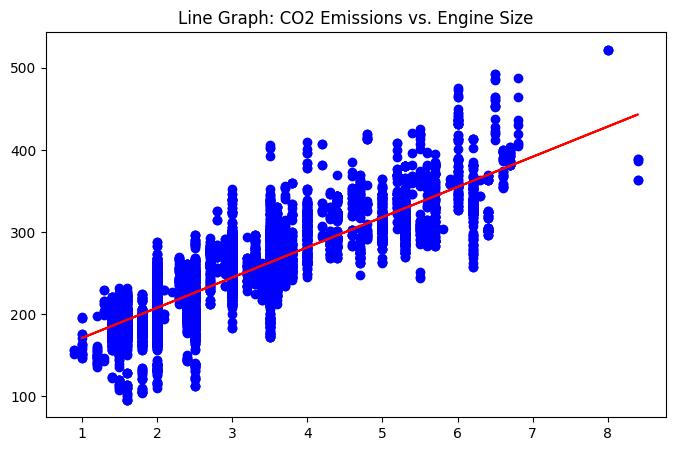

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='CO2 Emissions')  
plt.plot(x[:2954], y_pred[:2954], color='red', label='Fitted line')
plt.title('Line Graph: CO2 Emissions vs. Engine Size')
plt.show()


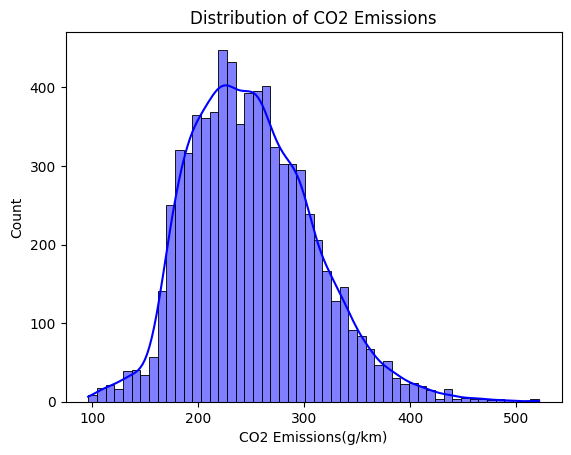

In [6]:
sns.histplot(df['CO2 Emissions(g/km)'], kde=True, color='blue')
plt.title('Distribution of CO2 Emissions')
plt.show()